# 🏦 PROJECT — Predicting Company Bankruptcies

## 📌 1. Problem Statement

Financial institutions face significant risks when lending to companies that may go bankrupt. The objective of this project is to develop a machine learning model that predicts company bankruptcy using financial indicators.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier


# Metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("Libraries are imported")

Libraries are imported


## 3. Load Dataset

In [2]:
df = pd.read_csv("Bankruptcies.csv")

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## 5. Data Understanding

In [3]:
df.shape

(6819, 96)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [5]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


### Target Distribution

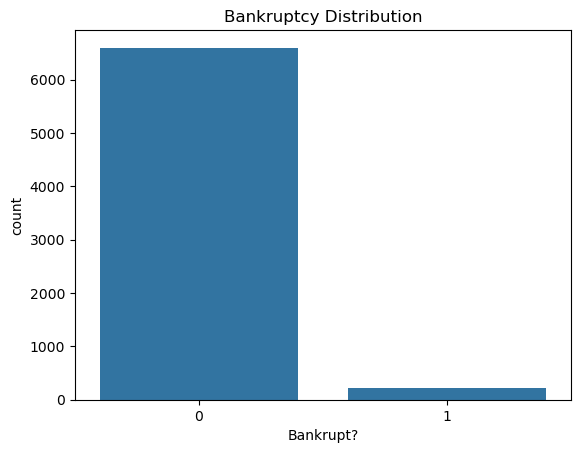

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

In [6]:
sns.countplot(x='Bankrupt?', data=df)
plt.title("Bankruptcy Distribution")
plt.show()

df['Bankrupt?'].value_counts(normalize=True)

In [7]:
df.isnull().sum().sum()

np.int64(0)

### Data Cleaning

In [8]:
# Remove spaces
df.columns = df.columns.str.strip()

# Convert to lowercase (optional but good)
df.columns = df.columns.str.lower()

# Replace spaces with underscore (optional)
df.columns = df.columns.str.replace(" ", "_")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   bankrupt?                                                6819 non-null   int64  
 1   roa(c)_before_interest_and_depreciation_before_interest  6819 non-null   float64
 2   roa(a)_before_interest_and_%_after_tax                   6819 non-null   float64
 3   roa(b)_before_interest_and_depreciation_after_tax        6819 non-null   float64
 4   operating_gross_margin                                   6819 non-null   float64
 5   realized_sales_gross_margin                              6819 non-null   float64
 6   operating_profit_rate                                    6819 non-null   float64
 7   pre-tax_net_interest_rate                                6819 non-null   float64
 8   after-tax_net_interest_rate 

## 6. Exploratory Data Analysis

### Corralation Heatmap

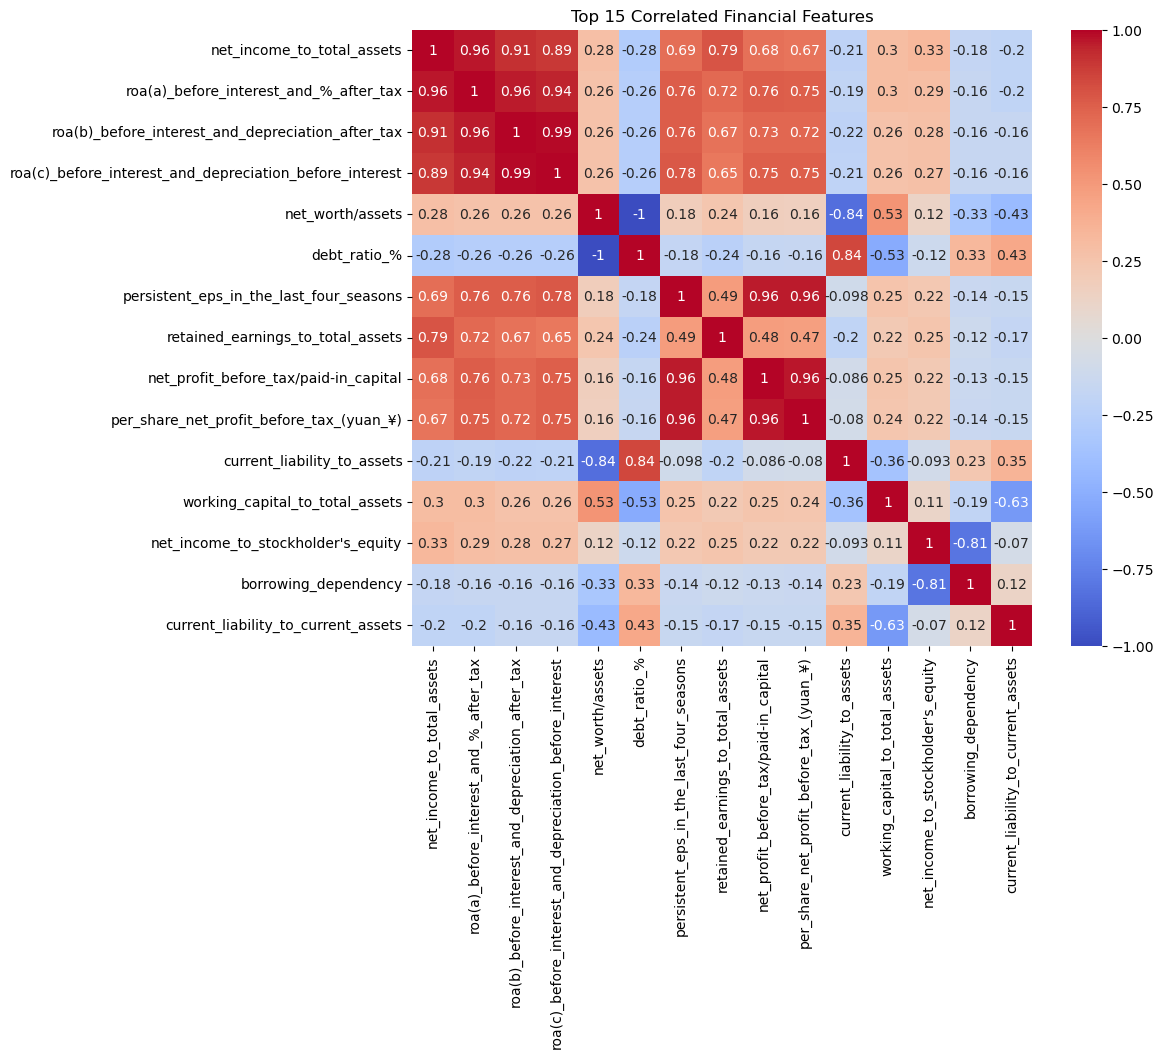

In [10]:
# Get absolute correlation values
corr = df.corr()["bankrupt?"].abs().sort_values(ascending=False)

# Select top 15 features (excluding target itself)
top_features = corr.index[1:16]

# Create correlation matrix of top features
top_corr_matrix = df[top_features].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(top_corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Top 15 Correlated Financial Features")
plt.show()

### Profitability vs Bankruptcy

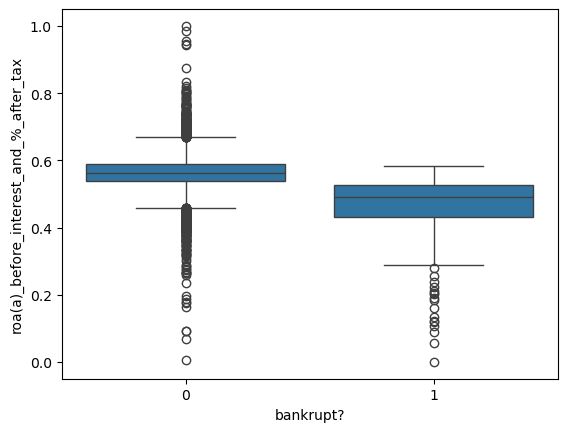

In [11]:
sns.boxplot(x='bankrupt?', y='roa(a)_before_interest_and_%_after_tax', data=df)
plt.show()

### Debt Ratio vs Bankruptcy

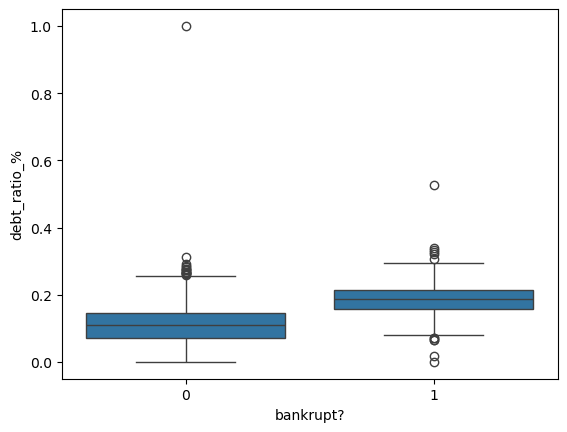

In [12]:
sns.boxplot(x='bankrupt?', y='debt_ratio_%', data=df)
plt.show()

### Liquidity vs Bankruptcy

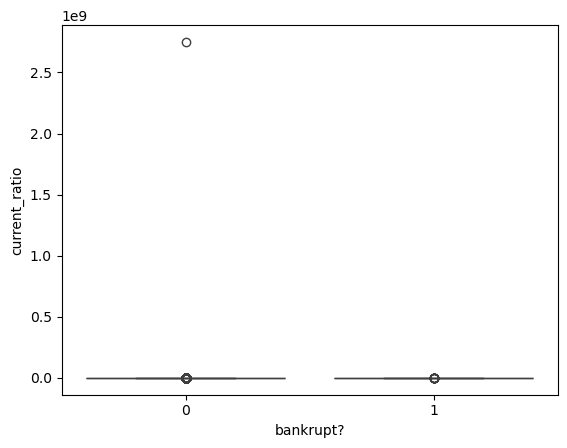

In [13]:
sns.boxplot(x='bankrupt?', y='current_ratio', data=df)
plt.show()

## 7. Feature Selection

### Remove Highly Correlated Features

In [14]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [column for column in upper.columns if any(upper[column] > 0.9)]
df = df.drop(columns=drop_cols)

## 8. Split Features & Target

In [15]:
X = df.drop('bankrupt?', axis=1)
y = df['bankrupt?']

## 9 . Strarified Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train distribution:\n", y_train.value_counts(normalize=True))
print("Test distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64
Test distribution:
 bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


- We used stratify=y to make sure the class distribution 
remains the same in both training and testing sets.

## 10. Cross Validation Strategy

In [17]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

- StratifiedKFold ensures each fold has balanced class distribution.

## 12.Model Selection

### Logistic Regression

In [18]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

### DecisionTreeClassifier

In [19]:
dt = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

### RandomForestClassifier

In [20]:
rf = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

## 14. Evaluate Models

### Logistic Regression

In [21]:
lr_param_dist = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]  # supports l1 and l2
}

lr_random = RandomizedSearchCV(
    lr,   
    param_distributions=lr_param_dist,
    n_iter=8,
    cv=skf,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

lr_random.fit(X_train, y_train)

print("Best LR Params:", lr_random.best_params_)

Best LR Params: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 0.01}


### DecisionTreeClassifier

In [22]:
dt_param_dist = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

dt_random = RandomizedSearchCV(
    dt,
    param_distributions=dt_param_dist,
    n_iter=10,
    cv=skf,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

dt_random.fit(X_train, y_train)

print("Best DT Params:", dt_random.best_params_)


Best DT Params: {'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 5, 'model__criterion': 'entropy'}


### RandomForestClassifier

In [23]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}


rf_random = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_dist,
    n_iter=12,
    cv=skf,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)


Best RF Params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 20}


In [24]:
best_lr = lr_random.best_estimator_
best_dt = dt_random.best_estimator_
best_rf = rf_random.best_estimator_

In [25]:
def test_evaluation(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [26]:
test_evaluation(best_lr, "Tuned Logistic Regression")
test_evaluation(best_dt, "Tuned Decision Tree")
test_evaluation(best_rf, "Tuned Random Forest")


Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1320
           1       0.18      0.86      0.29        44

    accuracy                           0.87      1364
   macro avg       0.59      0.87      0.61      1364
weighted avg       0.97      0.87      0.91      1364

ROC-AUC: 0.9381887052341598

Tuned Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.88      0.94      1320
           1       0.20      0.84      0.32        44

    accuracy                           0.88      1364
   macro avg       0.59      0.86      0.63      1364
weighted avg       0.97      0.88      0.92      1364

ROC-AUC: 0.9244490358126721

Tuned Random Forest
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1320
           1       0.37      0.73      0.49        44

    accuracy                           0.95      1364
   

In [27]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [28]:
def plot_roc_curve(model, X_test, y_test, model_name):
    
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()

#### Logistic regression

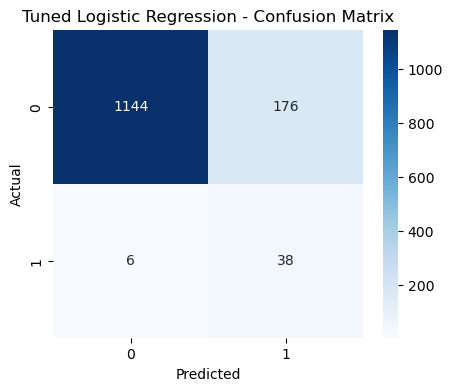

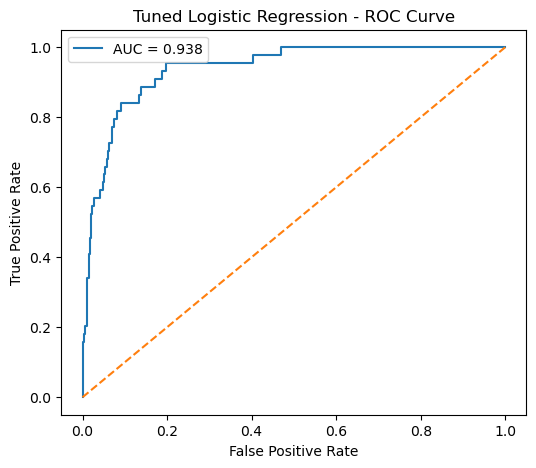

In [29]:
# Logistic Regression
plot_confusion_matrix(best_lr, X_test, y_test, "Tuned Logistic Regression")
plot_roc_curve(best_lr, X_test, y_test, "Tuned Logistic Regression")

### Decision Tree

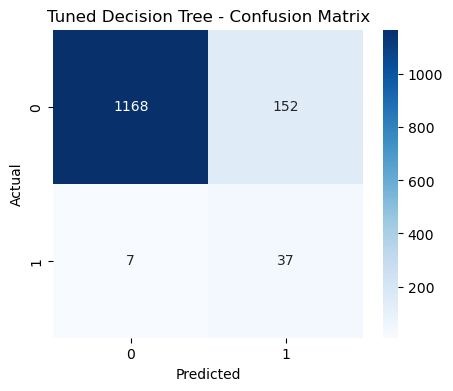

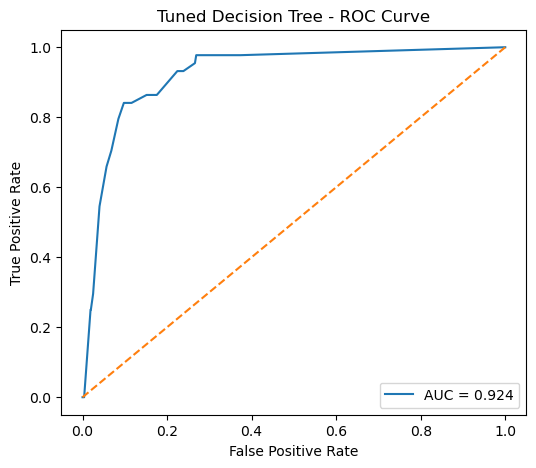

In [30]:
# Decision Tree
plot_confusion_matrix(best_dt, X_test, y_test, "Tuned Decision Tree")
plot_roc_curve(best_dt, X_test, y_test, "Tuned Decision Tree")

### Random Forest

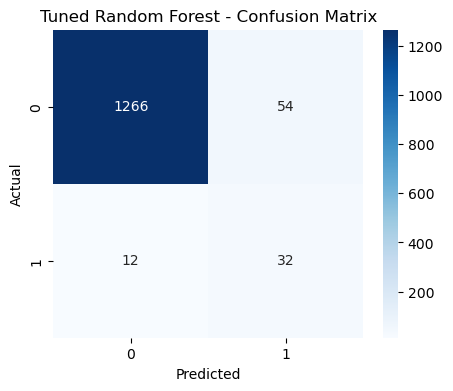

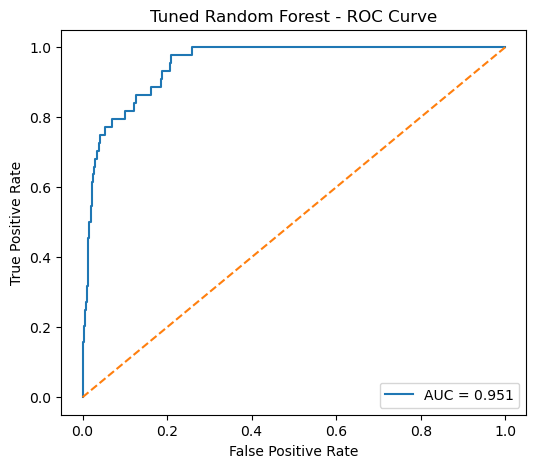

In [31]:
# Random Forest
plot_confusion_matrix(best_rf, X_test, y_test, "Tuned Random Forest")
plot_roc_curve(best_rf, X_test, y_test, "Tuned Random Forest")

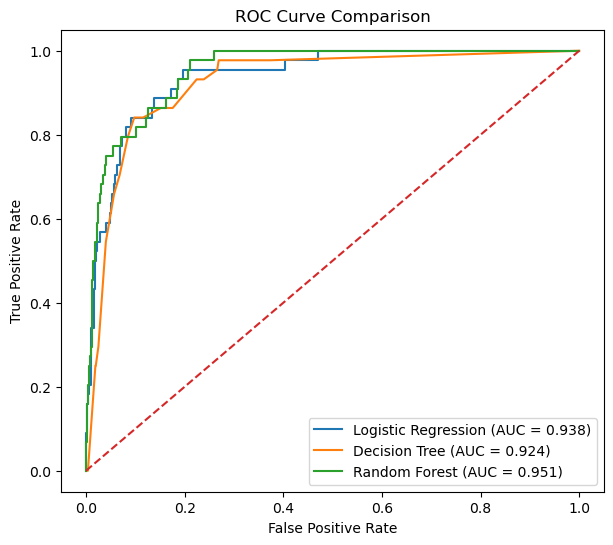

In [32]:
# Get probability predictions
lr_probs = best_lr.predict_proba(X_test)[:,1]
dt_probs = best_dt.predict_proba(X_test)[:,1]
rf_probs = best_rf.predict_proba(X_test)[:,1]

# Calculate ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Calculate AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot ROC curves
plt.figure(figsize=(7,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

# Random classifier line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#  <b> Final Model: Random Forest </b>

### <b>Precision–Recall Curve and Average Precision Evaluation</b>

Average Precision Score: 0.46701780839397944


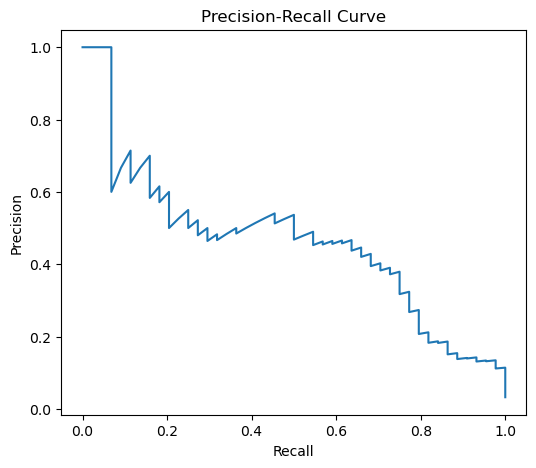

In [33]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Get predicted probabilities
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Compute precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Average Precision score
ap_score = average_precision_score(y_test, y_probs)

print("Average Precision Score:", ap_score)

# Plot
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

The Average Precision score of 0.467 indicates the model maintains moderate precision across varying recall levels, which is acceptable given the severe class imbalance.

## Threshold Optimization for Bankruptcy Risk

In [34]:
threshold_summary = pd.DataFrame({
    "Threshold": [0.30, 0.40, 0.50],
    "Precision (Bankrupt)": [0.22, 0.30, 0.37],
    "Recall (Bankrupt)": [0.80, 0.77, 0.73]
})

threshold_summary

,Threshold,Precision (Bankrupt),Recall (Bankrupt)
0,0.3,0.22,0.80
1,0.4,0.30,0.77
2,0.5,0.37,0.73


### <b>Final Threshold Selection</b>

Based on the trade-off between precision and recall for the bankrupt class, we selected 0.40 as the optimal threshold.

- At 0.30 → higher recall but excessive false positives.
- At 0.50 → better precision but increased risk of missing bankrupt firms.
- At 0.40 → balanced trade-off with 77% recall and improved precision.

Since missing bankrupt companies (false negatives) poses greater financial risk, a slightly lower threshold than the default 0.5 is justified.

In [35]:
best_thresh = 0.40
y_pred_optimal = (y_probs >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1320
           1       0.30      0.77      0.43        44

    accuracy                           0.93      1364
   macro avg       0.65      0.86      0.70      1364
weighted avg       0.97      0.93      0.95      1364



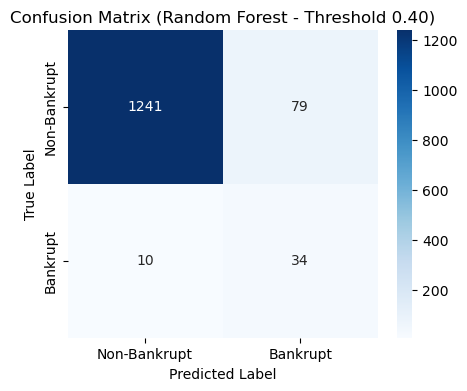

In [36]:
cm = confusion_matrix(y_test, y_pred_optimal)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Bankrupt", "Bankrupt"],
            yticklabels=["Non-Bankrupt", "Bankrupt"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Random Forest - Threshold 0.40)")
plt.show()

## Top 10 Feature Importances from Random Forest Model

Top 10 Important Features:
                                              Feature  Importance
10            persistent_eps_in_the_last_four_seasons    0.091490
28                               borrowing_dependency    0.061657
71                 net_income_to_stockholder's_equity    0.057233
25                         total_debt/total_net_worth    0.051433
54                  retained_earnings_to_total_assets    0.049825
55                         total_income/total_expense    0.048339
0   roa(c)_before_interest_and_depreciation_before...    0.042678
75                                equity_to_liability    0.040650
19                              net_value_growth_rate    0.036964
3         non-industry_income_and_expenditure/revenue    0.036336


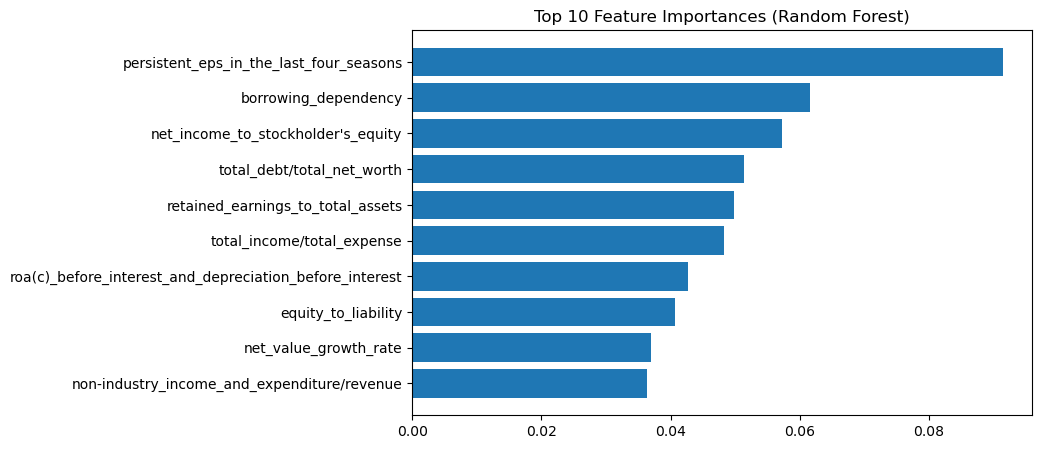

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get trained Random Forest model from pipeline
rf_model = best_rf.named_steps["model"]

# Get feature names (after preprocessing if any)
feature_names = X.columns

# Extract feature importance
importances = rf_model.feature_importances_

# Create dataframe
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort descending
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False)

# Top 10 features
top10 = feat_imp_df.head(10)

print("Top 10 Important Features:")
print(top10)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


## Business Insights (Finance-Oriented)

## 🔎 Key Observations

- The model correctly detects approximately 73% of financially distressed companies.
- Only 27% of bankrupt companies are missed.
- False positives exist but are manageable for manual review systems.
- ROC-AUC above 0.95 indicates strong ability to differentiate healthy vs distressed firms.

## Final Model Conclusion

After applying SMOTE, Stratified Cross-Validation, and Hyperparameter Tuning across three models, Random Forest demonstrated the best overall performance.

Key Results (Test Set):

- ROC-AUC: 0.951
- Recall (Bankrupt Class): 73%
- Precision (Bankrupt Class): 37%
- F1 Score: 0.49

The model successfully identified 73% of bankrupt companies while maintaining significantly better precision compared to Logistic Regression and Decision Tree.

Random Forest was selected as the final model due to its superior balance between detection capability and false alarm control.

<div style="background-color:#f0f0f0; padding:15px; color:#2e86c1; font-size:24px; font-weight:bold; text-align:center;">
    <b>Thank you<b/>
</div>